#Video Game Study - Google Colab
Using a smaller dataset of 50 entries, I practive cleanining methods, answering questions through EDA, and troubleshoot linear regression model issues.

In [177]:
# mounting my drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [178]:
# importing pandas and converting csv file to a dataframe

import pandas as pd

file_path = "/content/drive/MyDrive/COLAB DATASETS/best_selling_video_games.csv"

df= pd.read_csv(file_path)


In [179]:
df

,Rank,Title,Platform(s),Developer(s),Publisher(s),Ref.,Releaseyear,Sales(millions),Series,Table_Number
0,1,Minecraft,Multi-platform,Mojang Studios,Mojang Studios,NaN,2011[b],350,Minecraft,1
1,2,Grand Theft Auto V,Multi-platform,Rockstar North,Rockstar Games,NaN,2013,225,Grand Theft Auto,1
2,3,Wii Sports[a],Wii,Nintendo EAD,Nintendo,NaN,2006,82.9,Wii,1
3,4,Red Dead Redemption 2,Multi-platform,Rockstar Games,Rockstar Games,NaN,2018,82,Red Dead,1
4,5,Mario Kart 8/Deluxe,Wii U/Switch,Nintendo EAD/Nintendo EPD(Deluxe),Nintendo,[c],2014,79.05,Mario Kart,1
5,6,PUBG: Battlegrounds,Multi-platform,PUBG Studios,Krafton,NaN,2017,75,PUBG Universe,1
6,7,Terraria,Multi-platform,Re-Logic,Re-Logic/505 Games,NaN,2011,64,NaN,1
7,8,The Witcher 3: Wild Hunt,Multi-platform,CD Projekt Red,CD Projekt,NaN,2015,60,The Witcher,1
8,9,Super Mario Bros.[d],Multi-platform,Nintendo R&D4,Nintendo,NaN,1985,58,Super Mario,1
9,10,Human: Fall Flat,Multi-platform,No Brakes Games,Curve Digital,NaN,2016,55,NaN,1


## cleaning:

In [180]:
# creating a df with all the broken rows
broken_df = df[pd.to_numeric(df['Rank'], errors='coerce').isna()]
broken_df

,Rank,Title,Platform(s),Developer(s),Publisher(s),Ref.,Releaseyear,Sales(millions),Series,Table_Number
11,The Sims,50,2000,Electronic Arts,NaN,NaN,Maxis,The Sims,Multi-platform,1
12,Stardew Valley,50,2016,Chucklefish/ConcernedApe,NaN,NaN,ConcernedApe,NaN,Multi-platform,1
19,Payday 2,40,2013,505 Games,NaN,NaN,Overkill Software,Payday,Multi-platform,1
20,Sonic the Hedgehog[h],40,1991,Sega,NaN,NaN,Sonic Team,Sonic the Hedgehog,Multi-platform,1
25,Cyberpunk 2077,35,2020,CD Projekt,NaN,NaN,CD Projekt Red,Cyberpunk,Multi-platform,1
32,Borderlands 2,30,2012,2K Games,NaN,NaN,Gearbox Software,Borderlands,Multi-platform,1
33,Call of Duty: Black Ops Cold War,30,2020,Activision,NaN,NaN,Treyarch/Raven Software,Call of Duty,Multi-platform,1
34,The Elder Scrolls V: Skyrim,30,2011,Bethesda Softworks,NaN,NaN,Bethesda Game Studios,The Elder Scrolls,Multi-platform,1


In [181]:
# im going to just reindex the columns based on value order and swap the names of the columns manually

reorder = ['Publisher(s)', 'Rank', 'Series', 'Releaseyear', 'Developer(s)', 'Ref.', 'Platform(s)', 'Title', 'Sales(millions)', 'Table_Number']
new_broken_df = broken_df.reindex(columns=reorder)
new_broken_df

,Publisher(s),Rank,Series,Releaseyear,Developer(s),Ref.,Platform(s),Title,Sales(millions),Table_Number
11,NaN,The Sims,Multi-platform,Maxis,Electronic Arts,NaN,2000,50,The Sims,1
12,NaN,Stardew Valley,Multi-platform,ConcernedApe,Chucklefish/ConcernedApe,NaN,2016,50,NaN,1
19,NaN,Payday 2,Multi-platform,Overkill Software,505 Games,NaN,2013,40,Payday,1
20,NaN,Sonic the Hedgehog[h],Multi-platform,Sonic Team,Sega,NaN,1991,40,Sonic the Hedgehog,1
25,NaN,Cyberpunk 2077,Multi-platform,CD Projekt Red,CD Projekt,NaN,2020,35,Cyberpunk,1
32,NaN,Borderlands 2,Multi-platform,Gearbox Software,2K Games,NaN,2012,30,Borderlands,1
33,NaN,Call of Duty: Black Ops Cold War,Multi-platform,Treyarch/Raven Software,Activision,NaN,2020,30,Call of Duty,1
34,NaN,The Elder Scrolls V: Skyrim,Multi-platform,Bethesda Game Studios,Bethesda Softworks,NaN,2011,30,The Elder Scrolls,1


In [182]:
# renaming columns to match data
new_broken_df.rename(columns={'Publisher(s)': 'Rank', 'Rank': 'Title', 'Series':'Platform(s)', 'Releaseyear':'Developer(s)', 'Developer(s)':'Publisher(s)', 'Platform(s)' : 'Releaseyear', 'Title': 'Sales(millions)', 'Sales(millions)':'Series'}, inplace=True)
new_broken_df

,Rank,Title,Platform(s),Developer(s),Publisher(s),Ref.,Releaseyear,Sales(millions),Series,Table_Number
11,NaN,The Sims,Multi-platform,Maxis,Electronic Arts,NaN,2000,50,The Sims,1
12,NaN,Stardew Valley,Multi-platform,ConcernedApe,Chucklefish/ConcernedApe,NaN,2016,50,NaN,1
19,NaN,Payday 2,Multi-platform,Overkill Software,505 Games,NaN,2013,40,Payday,1
20,NaN,Sonic the Hedgehog[h],Multi-platform,Sonic Team,Sega,NaN,1991,40,Sonic the Hedgehog,1
25,NaN,Cyberpunk 2077,Multi-platform,CD Projekt Red,CD Projekt,NaN,2020,35,Cyberpunk,1
32,NaN,Borderlands 2,Multi-platform,Gearbox Software,2K Games,NaN,2012,30,Borderlands,1
33,NaN,Call of Duty: Black Ops Cold War,Multi-platform,Treyarch/Raven Software,Activision,NaN,2020,30,Call of Duty,1
34,NaN,The Elder Scrolls V: Skyrim,Multi-platform,Bethesda Game Studios,Bethesda Softworks,NaN,2011,30,The Elder Scrolls,1


In [183]:
# im going to drop and re-add this data back into the main df
df.drop(broken_df.index, inplace=True)
df = pd.concat([df, new_broken_df], ignore_index=True)
df


,Rank,Title,Platform(s),Developer(s),Publisher(s),Ref.,Releaseyear,Sales(millions),Series,Table_Number
0,1,Minecraft,Multi-platform,Mojang Studios,Mojang Studios,NaN,2011[b],350,Minecraft,1
1,2,Grand Theft Auto V,Multi-platform,Rockstar North,Rockstar Games,NaN,2013,225,Grand Theft Auto,1
2,3,Wii Sports[a],Wii,Nintendo EAD,Nintendo,NaN,2006,82.9,Wii,1
3,4,Red Dead Redemption 2,Multi-platform,Rockstar Games,Rockstar Games,NaN,2018,82,Red Dead,1
4,5,Mario Kart 8/Deluxe,Wii U/Switch,Nintendo EAD/Nintendo EPD(Deluxe),Nintendo,[c],2014,79.05,Mario Kart,1
5,6,PUBG: Battlegrounds,Multi-platform,PUBG Studios,Krafton,NaN,2017,75,PUBG Universe,1
6,7,Terraria,Multi-platform,Re-Logic,Re-Logic/505 Games,NaN,2011,64,NaN,1
7,8,The Witcher 3: Wild Hunt,Multi-platform,CD Projekt Red,CD Projekt,NaN,2015,60,The Witcher,1
8,9,Super Mario Bros.[d],Multi-platform,Nintendo R&D4,Nintendo,NaN,1985,58,Super Mario,1
9,10,Human: Fall Flat,Multi-platform,No Brakes Games,Curve Digital,NaN,2016,55,NaN,1


In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Rank             42 non-null     object
 1   Title            50 non-null     object
 2   Platform(s)      50 non-null     object
 3   Developer(s)     50 non-null     object
 4   Publisher(s)     50 non-null     object
 5   Ref.             10 non-null     object
 6   Releaseyear      50 non-null     object
 7   Sales(millions)  50 non-null     object
 8   Series           44 non-null     object
 9   Table_Number     50 non-null     int64 
dtypes: int64(1), object(9)
memory usage: 4.0+ KB


In [185]:
# dropping columns
   # rank is solely determined by sales so it will be removed to not skew data, ref is 80% null, table number values are all the same

df.drop(columns=['Rank','Ref.', 'Table_Number'], inplace=True)
df


,Title,Platform(s),Developer(s),Publisher(s),Releaseyear,Sales(millions),Series
0,Minecraft,Multi-platform,Mojang Studios,Mojang Studios,2011[b],350,Minecraft
1,Grand Theft Auto V,Multi-platform,Rockstar North,Rockstar Games,2013,225,Grand Theft Auto
2,Wii Sports[a],Wii,Nintendo EAD,Nintendo,2006,82.9,Wii
3,Red Dead Redemption 2,Multi-platform,Rockstar Games,Rockstar Games,2018,82,Red Dead
4,Mario Kart 8/Deluxe,Wii U/Switch,Nintendo EAD/Nintendo EPD(Deluxe),Nintendo,2014,79.05,Mario Kart
5,PUBG: Battlegrounds,Multi-platform,PUBG Studios,Krafton,2017,75,PUBG Universe
6,Terraria,Multi-platform,Re-Logic,Re-Logic/505 Games,2011,64,NaN
7,The Witcher 3: Wild Hunt,Multi-platform,CD Projekt Red,CD Projekt,2015,60,The Witcher
8,Super Mario Bros.[d],Multi-platform,Nintendo R&D4,Nintendo,1985,58,Super Mario
9,Human: Fall Flat,Multi-platform,No Brakes Games,Curve Digital,2016,55,NaN


In [186]:
# creating a dictionary to fix typos

typo_dict = {
    'Wii Sports[a]': 'Wii Sports',
    '2011[b]': '2011',
    'Super Mario Bros.[d]': 'Super Mario Bros',
    'Wii Fit/Plus[f]': 'Wii Fit/Plus',
    'Mario Kart Wii[i]': 'Mario Kart Wii',
    'Tetris(Game Boy)[k]': 'Tetris(Game Boy)',
    'Wii Sports Resort[l]': 'Wii Sports Resort',
    'Duck Hunt[o]': 'Duck Hunt',
    'Wii Play[p]': 'Wii Play',
    'Sonic the Hedgehog[h]': 'Sonic the Hedgehog'
}

df['Title'] = df['Title'].replace(typo_dict)
df['Releaseyear'] = df['Releaseyear'].replace(typo_dict)
df

,Title,Platform(s),Developer(s),Publisher(s),Releaseyear,Sales(millions),Series
0,Minecraft,Multi-platform,Mojang Studios,Mojang Studios,2011,350,Minecraft
1,Grand Theft Auto V,Multi-platform,Rockstar North,Rockstar Games,2013,225,Grand Theft Auto
2,Wii Sports,Wii,Nintendo EAD,Nintendo,2006,82.9,Wii
3,Red Dead Redemption 2,Multi-platform,Rockstar Games,Rockstar Games,2018,82,Red Dead
4,Mario Kart 8/Deluxe,Wii U/Switch,Nintendo EAD/Nintendo EPD(Deluxe),Nintendo,2014,79.05,Mario Kart
5,PUBG: Battlegrounds,Multi-platform,PUBG Studios,Krafton,2017,75,PUBG Universe
6,Terraria,Multi-platform,Re-Logic,Re-Logic/505 Games,2011,64,NaN
7,The Witcher 3: Wild Hunt,Multi-platform,CD Projekt Red,CD Projekt,2015,60,The Witcher
8,Super Mario Bros,Multi-platform,Nintendo R&D4,Nintendo,1985,58,Super Mario
9,Human: Fall Flat,Multi-platform,No Brakes Games,Curve Digital,2016,55,NaN


In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Title            50 non-null     object
 1   Platform(s)      50 non-null     object
 2   Developer(s)     50 non-null     object
 3   Publisher(s)     50 non-null     object
 4   Releaseyear      50 non-null     object
 5   Sales(millions)  50 non-null     object
 6   Series           44 non-null     object
dtypes: object(7)
memory usage: 2.9+ KB


In [188]:
# all null values in the Series column all represent games that were released as single entities. Therefore I will just fill the nulls with "single" so they can be categorized

df['Series'].fillna('Single', inplace=True)

/tmp/ipython-input-968561234.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Series'].fillna('Single', inplace=True)


In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Title            50 non-null     object
 1   Platform(s)      50 non-null     object
 2   Developer(s)     50 non-null     object
 3   Publisher(s)     50 non-null     object
 4   Releaseyear      50 non-null     object
 5   Sales(millions)  50 non-null     object
 6   Series           50 non-null     object
dtypes: object(7)
memory usage: 2.9+ KB


In [190]:
df.tail(10)

,Title,Platform(s),Developer(s),Publisher(s),Releaseyear,Sales(millions),Series
40,Garry's Mod,PC,Facepunch Studios,Valve,2006,25.56,Single
41,Pokémon Diamond/Pearl/Platinum,Nintendo DS,Game Freak,Nintendo/The Pokémon Company,2006,25.5,Pokémon
42,The Sims,Multi-platform,Maxis,Electronic Arts,2000,50,The Sims
43,Stardew Valley,Multi-platform,ConcernedApe,Chucklefish/ConcernedApe,2016,50,Single
44,Payday 2,Multi-platform,Overkill Software,505 Games,2013,40,Payday
45,Sonic the Hedgehog,Multi-platform,Sonic Team,Sega,1991,40,Sonic the Hedgehog
46,Cyberpunk 2077,Multi-platform,CD Projekt Red,CD Projekt,2020,35,Cyberpunk
47,Borderlands 2,Multi-platform,Gearbox Software,2K Games,2012,30,Borderlands
48,Call of Duty: Black Ops Cold War,Multi-platform,Treyarch/Raven Software,Activision,2020,30,Call of Duty
49,The Elder Scrolls V: Skyrim,Multi-platform,Bethesda Game Studios,Bethesda Softworks,2011,30,The Elder Scrolls


In [191]:
# finally im just going to rename the columns for easier use (kind of late now but still)
df.rename(columns={'Platform(s)': 'Platform', 'Developer(s)': 'Developer', 'Publisher(s)': 'Publisher', 'Releaseyear': 'Year', 'Sales(millions)': 'Sales'}, inplace=True)
df

,Title,Platform,Developer,Publisher,Year,Sales,Series
0,Minecraft,Multi-platform,Mojang Studios,Mojang Studios,2011,350,Minecraft
1,Grand Theft Auto V,Multi-platform,Rockstar North,Rockstar Games,2013,225,Grand Theft Auto
2,Wii Sports,Wii,Nintendo EAD,Nintendo,2006,82.9,Wii
3,Red Dead Redemption 2,Multi-platform,Rockstar Games,Rockstar Games,2018,82,Red Dead
4,Mario Kart 8/Deluxe,Wii U/Switch,Nintendo EAD/Nintendo EPD(Deluxe),Nintendo,2014,79.05,Mario Kart
5,PUBG: Battlegrounds,Multi-platform,PUBG Studios,Krafton,2017,75,PUBG Universe
6,Terraria,Multi-platform,Re-Logic,Re-Logic/505 Games,2011,64,Single
7,The Witcher 3: Wild Hunt,Multi-platform,CD Projekt Red,CD Projekt,2015,60,The Witcher
8,Super Mario Bros,Multi-platform,Nintendo R&D4,Nintendo,1985,58,Super Mario
9,Human: Fall Flat,Multi-platform,No Brakes Games,Curve Digital,2016,55,Single


In [192]:
# Year and Sales can be recognized as int/float
df['Year'] = df['Year'].astype(int)
df['Sales'] = df['Sales'].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Title      50 non-null     object 
 1   Platform   50 non-null     object 
 2   Developer  50 non-null     object 
 3   Publisher  50 non-null     object 
 4   Year       50 non-null     int64  
 5   Sales      50 non-null     float64
 6   Series     50 non-null     object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ KB


## EDA:

In [193]:
df.describe()

,Year,Sales
count,50.000000,50.00000
mean,2011.140000,49.70900
std,9.551173,52.95549
min,1984.000000,25.50000
25%,2006.250000,28.13500
50%,2013.000000,35.00000
75%,2018.000000,49.83000
max,2024.000000,350.00000


**What games have made it over 100 million in sales?**

Only Minecraft (at 350 million) and GTA V (at 225 million).



In [194]:
df[df['Sales'] > 100]

,Title,Platform,Developer,Publisher,Year,Sales,Series
0,Minecraft,Multi-platform,Mojang Studios,Mojang Studios,2011,350.0,Minecraft
1,Grand Theft Auto V,Multi-platform,Rockstar North,Rockstar Games,2013,225.0,Grand Theft Auto


**Average sales per platform?**

Wii U/Switch sales have dominated over all Multi-platform sales in the top 50. It is safe to assume platform exclusivity is not always a hinderance to sales!

In [195]:
df.groupby('Platform')['Sales'].mean().sort_values(ascending=False)

,Sales
Platform,
Wii U/Switch,79.050000
Multi-platform,59.485517
Wii,42.593333
Game Boy,35.000000
Nintendo Switch,34.438000
Game Boy Color,30.120000
Famicom / NES,28.300000
Nintendo DS,28.150000
PS3/PS4,26.600000


**Nintendo is the most frequent publisher in the dataset. How often were they publishing top-rated games?**

Nintendo on average, publishes a new, top-rated game every 2.25 years.

In [196]:
nintendo_years = df[(df['Publisher'] == 'Nintendo')][['Publisher','Title','Year']].sort_values('Year', ascending=False)
nintendo_years

,Publisher,Title,Year
11,Nintendo,Animal Crossing: New Horizons,2020
17,Nintendo,Super Smash Bros. Ultimate,2018
19,Nintendo,The Legend of Zelda: Breath of the Wild,2017
24,Nintendo,Super Mario Odyssey,2017
4,Nintendo,Mario Kart 8/Deluxe,2014
23,Nintendo,New Super Mario Bros. Wii,2009
21,Nintendo,Wii Sports Resort,2009
18,Nintendo,Mario Kart Wii,2008
13,Nintendo,Wii Fit/Plus,2007
2,Nintendo,Wii Sports,2006


In [197]:
year_diff = nintendo_years['Year'].diff()
avg_year = abs(year_diff.mean())
avg_year

np.float64(2.25)

**Which gaming series are *least* profitable (according to salescount)?**

Below are the top 5, *lowest* sold games:

In [198]:
df.groupby('Series')['Sales'].sum().sort_values(ascending=True).head()

,Sales
Series,
Marvel's Spider-Man,26.1
The Last of Us,26.6
Black Myth,28.0
Monster Hunter,29.1
Elden Ring,30.0


**Which gaming developer is *least* profitable (according to salescount)?**

Below are the top 5, *lowest* performing developers:

In [199]:
df.groupby('Developer')['Sales'].sum().sort_values(ascending=True).head()

,Sales
Developer,
Facepunch Studios,25.56
Insomniac Games,26.10
Infinity Ward/Sledgehammer,26.50
Naughty Dog,26.60
Hazelight Studios,27.00


**correlation between predictors:**

## building a model
I will use a linear regression model with sales as the predictor


In [200]:
# dropping to reduce noise
model1_df = df.drop(columns=['Title','Developer','Publisher','Series'])

In [201]:
# creating dummy variables

model1_df = pd.get_dummies(model1_df, drop_first=True).astype(int)

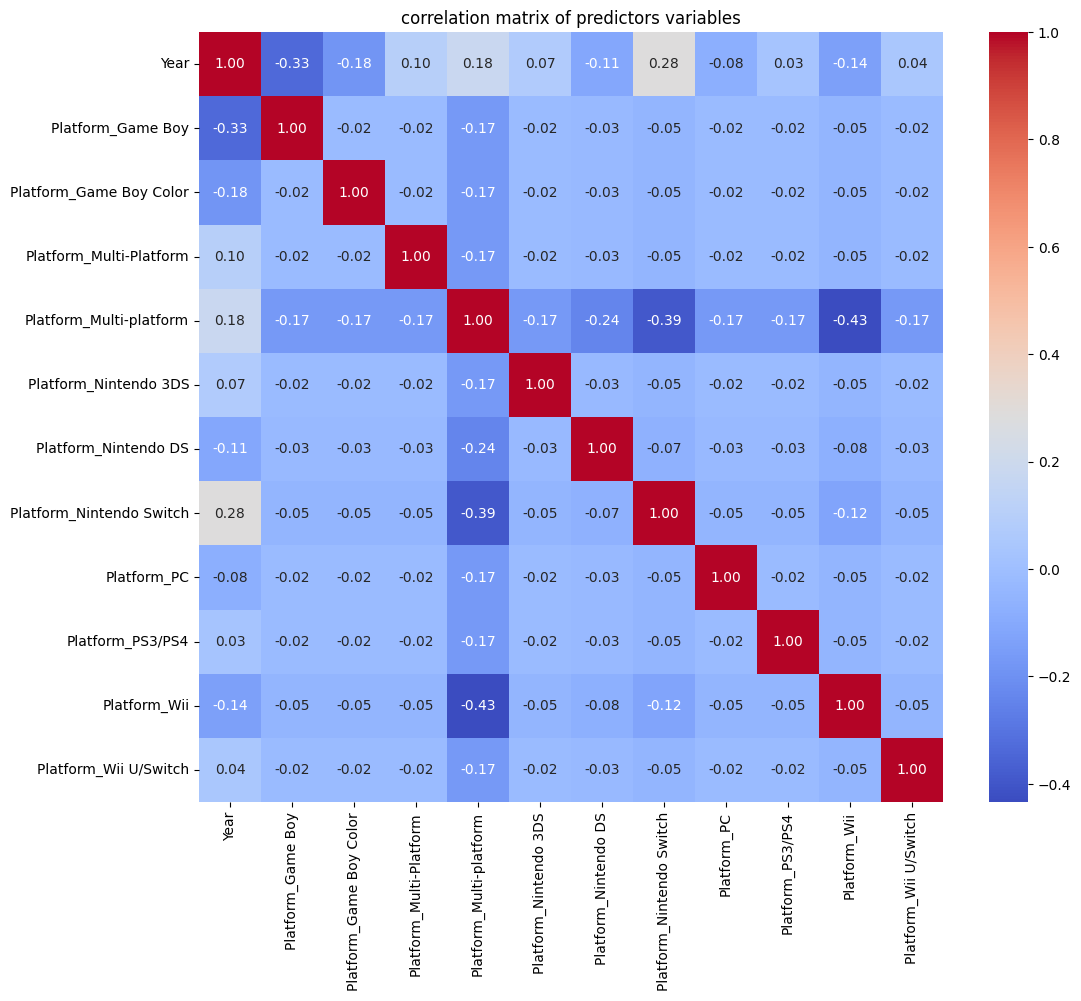

In [202]:
import seaborn as sns
import matplotlib.pyplot as plt

# excluding 'Sales'
predictors = model1_df.drop(columns=['Sales'])

# Calculate the correlation matrix
correlation_matrix = predictors.corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('correlation matrix of predictors variables')
plt.show()

*takeaway*: There is high correlation between a lot of variables.

**why?**:
* nintendo is a publisher who only makes games on nintendo platforms
* series are determined by publishers and developers
* developers determine publishers

**now what?**
I will make a small model with few predictors that do not overlap like Year and Platform

In [203]:
model1_df.head()

,Year,Sales,Platform_Game Boy,Platform_Game Boy Color,Platform_Multi-Platform,Platform_Multi-platform,Platform_Nintendo 3DS,Platform_Nintendo DS,Platform_Nintendo Switch,Platform_PC,Platform_PS3/PS4,Platform_Wii,Platform_Wii U/Switch
0,2011,350,0,0,0,1,0,0,0,0,0,0,0
1,2013,225,0,0,0,1,0,0,0,0,0,0,0
2,2006,82,0,0,0,0,0,0,0,0,0,1,0
3,2018,82,0,0,0,1,0,0,0,0,0,0,0
4,2014,79,0,0,0,0,0,0,0,0,0,0,1


In [204]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = model1_df.drop(columns=['Sales'])
y = model1_df['Sales']

In [205]:
# using kfold cross-validation (learning it)
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

k=5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

In [206]:
model = LinearRegression()

In [207]:
scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

In [208]:
import numpy as np

average_r2 = np.mean(scores)
print(f"r^2 score for each fold: {[round(score, 4) for score in scores]}")
print(f"Average R2 across {k} folds: {average_r2:.4f}")

r^2 score for each fold: [np.float64(-20.7849), np.float64(-2.4594), np.float64(-0.0296), np.float64(0.0438), np.float64(-1.3939)]
Average R2 across 5 folds: -4.9248


**Note**: My inital r^2 was -99.

The insanely low accuracy is likely due to the large number of columns in the dataset (94 now with dummy variables) and a low amount of entries.

Gemini suggestions are to implement a  ridge model which I will inlcude below:

In [209]:
from sklearn.linear_model import Ridge

# Initialize Ridge Regression model
# Alpha is the regularization strength; a good starting point can be found through cross-validation
ridge_model = Ridge(alpha=1.0, random_state=42)

# Perform cross-validation with the Ridge model
ridge_scores = cross_val_score(ridge_model, X, y, cv=kf, scoring='r2')

# Calculate the average R2 score for the Ridge model
average_ridge_r2 = np.mean(ridge_scores)

print(f"Ridge R^2 scores for each fold: {[round(score, 4) for score in ridge_scores]}")
print(f"Average Ridge R2 across {k} folds: {average_ridge_r2:.4f}")

# If this is still low, further steps might involve feature selection, more data, or different models.


Ridge R^2 scores for each fold: [np.float64(-17.3008), np.float64(-0.7926), np.float64(-0.0344), np.float64(0.038), np.float64(-1.2735)]
Average Ridge R2 across 5 folds: -3.8727


## Summary

**what did I do?**

I was able to practice data cleaning and answer quering/eda questions. I attempted to fit a linear regression model to be able to predict sales volume in newly released games.

**challenges**

I was not able to accurately fit a model to the data. The dataset I used was small with only 50 entries. Additionally, there were issues with multicollinearity. Apon initally fitting a model and receving a r^2 score of -99 and high K Fold score values, added a correlation matrix to get a better preview of the predictors interactions.

This dataset lacks a large amount of entries to train a model on, and extensive column data to use as predictors.

**what can I do different?**

I will first find a larger dataset with less overlaying data. However, when developing a model, I could firther investigate different methods that fit the data better. I can also do more EDA prior to preforming a model to get a better idea of the data I am dealing with and predict any challeneges ahead of time.


Overall, however, I learned new techniques to better fit data and, even with a more difficult dataset, managed to reduce my r^2 scoring from a -99 to 4.9 :)